In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_curve, auc
from sklearn.metrics import accuracy_score, recall_score, roc_curve, auc

In [24]:
df=pd.read_excel('./Data/IMT_Classification_Dataset_Reduced_Feature_Set_v10.xlsx')
df.head()

,Compound,Label,struct_file_path,gii,est_hubbard_u,est_charge_trans,ewald_energy_per_atom,avg_dev_Electronegativity,range_MendeleevNumber,avg_dev_CovalentRadius,avg_mm_dists,avg_mx_dists,avg_xx_dists
0,Ba(FeSb3)4,0,../data/Structures/Metals/BaFe4Sb12_CollCode_6...,0.000000,21.129322,19.461062,-12.916613,0.169412,76,8.608997,4.601000,2.596481,3.266718
1,Ba(NiP)2,0,../data/Structures/Metals/BaNi2P2_SD_1701656.cif,1.080042,11.858755,35.445979,-29.022094,0.371200,74,31.840000,2.790950,2.259574,3.631725
2,Ba(PIr)2,0,../data/Structures/Metals/BaIr2P2_CollCode_957...,3.015802,5.839285,34.042180,-27.929343,0.417600,74,29.120000,2.790243,2.355169,3.754372
3,Ba(PRh)2,0,../data/Structures/Metals/BaRh2P2_CollCode_501...,1.337935,7.810114,33.195560,-28.030653,0.430400,74,28.960000,2.785294,2.346291,3.757078
4,Ba(Sb3Os)4,0,../data/Structures/Metals/BaOs4Sb12_CollCode_6...,1.037038,12.916563,10.425355,-12.725768,0.132595,76,8.276817,4.670000,2.635420,3.315708


In [25]:
df.Label.unique()
# Filter the DataFrame to exclude rows where Label is 2
filtered_df = df[df['Label'] != 2]

In [30]:
# Drop unnecessary columns and separate features (X) and labels (y)
X = filtered_df.drop(columns=['struct_file_path', 'Label', 'Compound'])
y = filtered_df['Label']
X_reduced=filtered_df[['est_hubbard_u','est_charge_trans']]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train_reduced, X_test_reduced, y_train, y_test = train_test_split(X_reduced, y, test_size=0.3, random_state=42)

-----
- Key Reasons for Feature Scaling: Equal Contribution,Improved Convergence Speed, Enhanced Model Performance,Numerical Stability,Interpretability

In [7]:
scaler = StandardScaler()
# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaler_reduced= StandardScaler()
# Fit the scaler on the training data and transform both training and testing data
X_train_reduced_scaled = scaler_reduced.fit_transform(X_train_reduced)
X_test_reduced_scaled = scaler_reduced.transform(X_test_reduced)

----

In [8]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [9]:
model_bad = LogisticRegression()
model_bad.fit(X_train_reduced_scaled, y_train)

LogisticRegression()

------

In [10]:
# Make predictions
y_pred = model.predict(X_test_scaled)
y_pred_reduced= model_bad.predict(X_test_reduced_scaled)

-----
Accuracy = True Positive/ (True Positive+False Negative) 
Recall = True Positive/(True positive+false negative)

In [11]:
# Calculate accuracy  
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
# Calculate accuracy  
accuracy = accuracy_score(y_test, y_pred_reduced)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.75
Accuracy: 0.61


In [13]:
# Calculate ROC curve and AUC
y_scores = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

y_scores_reduced = model_bad.predict_proba(X_test_reduced_scaled)[:, 1]
fpr_reduced, tpr_reduced, thresholds_reduced = roc_curve(y_test, y_scores_reduced)
roc_auc_reduced= auc(fpr_reduced, tpr_reduced)

In [21]:
# save metrics
import pickle
metrics=dict(fpr=fpr, tpr=tpr,roc_auc=roc_auc,fpr_reduced=fpr_reduced, tpr_reduced=tpr_reduced,roc_auc_reduced=roc_auc_reduced)
with open('logreg_metrics.pkl', 'wb') as f:
    pickle.dump(metrics, f)

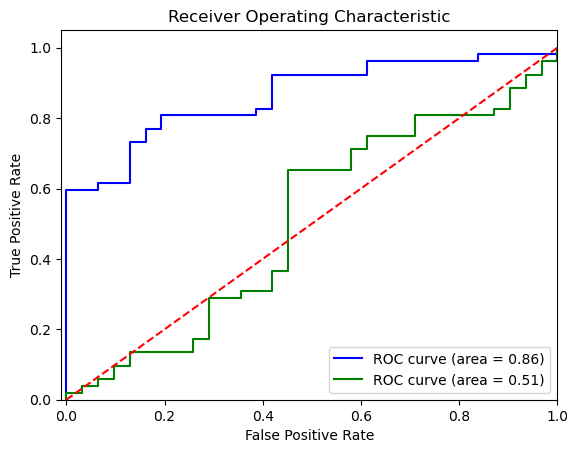

In [90]:
# Plot ROC Curve (optional)
import matplotlib.pyplot as plt

plt.figure()
plt.plot(fpr, tpr, color='blue', label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot(fpr_reduced, tpr_reduced, color='green', label='ROC curve (area = {:.2f})'.format(roc_auc_))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()